In [18]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import pyro
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
import pyro.distributions as dist
from pyro.infer import Predictive
from pyro.optim import Adam
from tqdm import tqdm

## ''SVI objects''

In [19]:
class Reservoir(nn.Module):
    def __init__(self, N, K, spectral_radius=0.9):
        super(Reservoir, self).__init__()
        
        self.N = N  # Number of reservoir neurons
        self.K = K  # Input dimension

        
        # Initialize Input Matrix (Uniform distribution is common)
        W_in = torch.rand(N, K) * 2 - 1  # Range [-1, 1]
        
        # Initialize Reservoir Matrix (Gaussian)
        W = torch.randn(N, N)
        
        # Scale Spectral Radius for stability
        # We calculate the largest eigenvalue and scale W
        with torch.no_grad():
            # Use real/imaginary parts to find the magnitude of eigenvalues
            eigenvalues = torch.linalg.eigvals(W)
            max_eig = torch.max(torch.abs(eigenvalues))
            W = W * (spectral_radius / max_eig)
        
        # Register as buffers (Fixed weights, move with model to GPU)
        self.register_buffer('W_in', W_in)
        self.register_buffer('W', W)
        
        # Internal state (Initialized to zeros)
        self.register_buffer('states', torch.zeros(1, N))
        
        self.activation = torch.tanh

    def forward(self, x, y = None):
        """
        x shape: [Batch, K]
        Returns the updated state: [Batch, N]
        """
        
        # Linear combinations: Input effect + Reservoir recurrent effect
        # We use .t() on weights because x is [Batch, K] and states is [Batch, N]
        input_part = x @ self.W_in.t()
        recurrent_part = self.states @ self.W.t()
        
        # We .detach() to ensure we don't track gradients through time steps
        self.states = self.activation(input_part + recurrent_part).detach()
        
        return self.states

    def reset_state(self, batch_size=1):
        """Clears the memory of the reservoir."""
        self.states = torch.zeros(batch_size, self.N, device=self.W.device)

In [20]:
class ESNDataset(torch.utils.data.Dataset):
    def __init__(self, states, predictions, mean=None, std=None):
        
        if mean is None or std is None:
            self.mean = predictions.mean()
            self.std = predictions.std()
        else:
            self.mean = mean
            self.std = std
            
        self.normalized_predictions = (predictions - self.mean) / self.std
        self.states = states 
    
    def __len__(self):
        return len(self.normalized_predictions)

    def __getitem__(self, index):
        return self.states[index], self.normalized_predictions[index]

In [21]:
class ESNVariational:
    def __init__(self, N, K, pyro_model, pyro_guide, optimizer, spectral_radius = 0.9):
        
        # constructor attributes
        self.reservoir = Reservoir(N,K,spectral_radius=spectral_radius)
        self.pyro_model = pyro_model
        self.pyro_guide = pyro_guide
        self.optimizer = optimizer
        self.svi = SVI(self.pyro_model,self.pyro_guide,self.optimizer,loss = Trace_ELBO())

        # storage for Metrics
        self.loss_history = []

    def train(self, train_loader, epochs=500):
        """
        Training using a PyTorch DataLoader for mini-batch SVI.
        train_loader: Should yield (batch_states, batch_targets)
        """
        pbar = tqdm(range(epochs), desc="Training Pyro ESN")
        
        # Determine total dataset size for averaging loss
        dataset_size = len(train_loader.dataset)

        for epoch in pbar:
            epoch_loss = 0.0
            
            # Iterate over mini-batches
            for batch_states, batch_targets in train_loader:
                # SVI.step updates parameters based on this specific batch
                # It returns the ELBO loss for the batch
                loss = self.svi.step(batch_states, batch_targets)
                epoch_loss += loss
            
            # Normalize loss by the total number of samples in the dataset
            avg_epoch_loss = epoch_loss / dataset_size
            self.loss_history.append(avg_epoch_loss)
            
            # Update progress bar every epoch, print details every 100
            if epoch % 100 == 0:
                print(f"Epoch {epoch} | Total ELBO Loss: {avg_epoch_loss:.4f}")
            
            pbar.set_postfix({"Loss": f"{avg_epoch_loss:.4f}"})
        
        return self.loss_history

    # evaluation
    def predict(self, test_states, num_samples = 1000):
        """
        Generate ''num_samples'' independent predictions for each state given the learned weights
        """
        predictive_object = Predictive(self.pyro_model, guide = self.pyro_guide, num_samples = num_samples)
        with torch.no_grad():
            samples = predictive_object(test_states, None) # None --> sampling mode, not inference
        
        y_samples = samples["obs"]
        # Squeeze in case Pyro returns [Samples, 1, Time] instead of [Samples, Time]
        return y_samples.squeeze()

        

## dataset handling

In [22]:
def construct_dataset(reservoir: Reservoir, time_series, burnin = 50, train_split = 0.7, print_stats = False):
    """
    Function that takes as input a time series and gives a torch.utils.dataset object to 
    perform the training/testing
    """
    # Compute states for each input data
    L = len(time_series) 
    reservoir.reset_state(batch_size=1)

    states = torch.zeros(L,reservoir.N)
    for t in range(L):
        sample = reservoir(time_series[t])
        with torch.no_grad():
            states[t] = sample
    
    # Exclude burn_in to avoid dependence from initial input
    cleaned_states = states[burnin:-1]
    cleaned_time_series = time_series[burnin+1:]

    # Calculate split index
    split_index = int(L * train_split)

    # Divide training and test
    train_data_raw = cleaned_time_series[:split_index].view(-1)
    train_states_raw = cleaned_states[:split_index]

    test_data_raw = cleaned_time_series[split_index:].view(-1)
    test_states_raw = cleaned_states[split_index:]

    # compute mean and variance for training as control
    mu = train_data_raw.mean()
    sigma = train_data_raw.std()
    
    if print_stats:
        print(f"Mean targets = {mu:.4f}")
        print(f"Std targets = {sigma:.4f}")

    train_data = ESNDataset(train_states_raw, train_data_raw, mu, sigma)
    test_data = ESNDataset(test_states_raw, test_data_raw, mu, sigma)   

    return train_data, test_data 


## evaluation

In [23]:
def prediction_curve(esnvariational_object: ESNVariational, test_dataset: ESNDataset, scaler: dict, title = "Predicted vs actual data"):
    
    y_samples = esnvariational_object.predict(test_states=test_dataset.states)
    y_true = test_dataset.normalized_predictions
    
    if scaler:
        m, s = scaler['mean'], scaler['std']
        y_samples = (y_samples * s) + m
        y_true = (y_true * s) + m

    mean_pred = y_samples.mean(dim=0)
    lower_bound = torch.quantile(y_samples, 0.025, dim=0) # 95% CI Lower
    upper_bound = torch.quantile(y_samples, 0.975, dim=0) # 95% CI Upper

    plt.figure(figsize=(12, 5))
    plt.plot(y_true, label="Actual Load", color="black", alpha=0.6)
    plt.plot(mean_pred, label="Bayesian Mean", color="blue")
    
    plt.fill_between(
        range(len(mean_pred)), 
        lower_bound, 
        upper_bound, 
        color="blue", alpha=0.2, label="95% Confidence"
    )
    
    plt.title(title)
    plt.legend()
    plt.show()

    return y_true, mean_pred, lower_bound, upper_bound




## Test pipeline

In [24]:
# generate data
T = 1000
time = torch.linspace(0, 100, T)
time_series = torch.sin(time) + torch.randn(T) * 0.1  # Signal + Noise
time_series = time_series.view(-1, 1) # Ensure [L, 1] shape

In [ ]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 1), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R).squeeze(-1)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(0.1))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma), obs=targets)


In [26]:
# PYRO GUIDE

RANK = 10  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

In [27]:
# PARAMETERS

N_NEURONS = 100
INPUT_DIM = 1 # equals to output dim

LR = 0.005
EPOCHS = 300

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": LR})

In [38]:
# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius=2
)


In [39]:
# Generate Torch datasets
train_ds, test_ds = construct_dataset(esn_var.reservoir, time_series, burnin=50)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [40]:
# TRAIN
history = esn_var.train(train_loader, epochs=EPOCHS)

Training Pyro ESN:   1%|          | 3/300 [00:00<00:28, 10.39it/s, Loss=10.5526]

Epoch 0 | Total ELBO Loss: 14.4568


Training Pyro ESN:  34%|███▍      | 103/300 [00:07<00:13, 15.08it/s, Loss=4.4717]

Epoch 100 | Total ELBO Loss: 4.4651


Training Pyro ESN:  68%|██████▊   | 203/300 [00:13<00:06, 14.77it/s, Loss=4.5856]

Epoch 200 | Total ELBO Loss: 4.4383


Training Pyro ESN: 100%|██████████| 300/300 [00:20<00:00, 14.74it/s, Loss=4.3709]


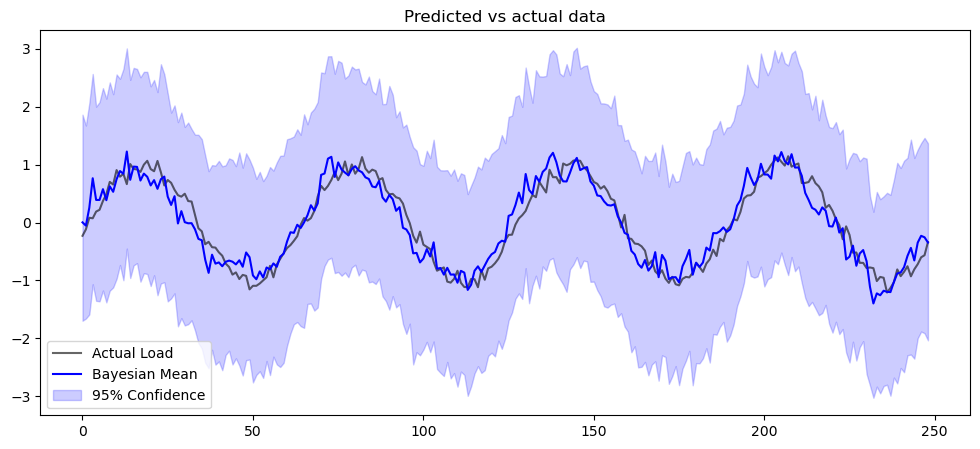

In [41]:
# PREDICT & PLOT
scaler = {'mean': train_ds.mean, 'std': train_ds.std}
results = prediction_curve(esn_var, test_ds, scaler)

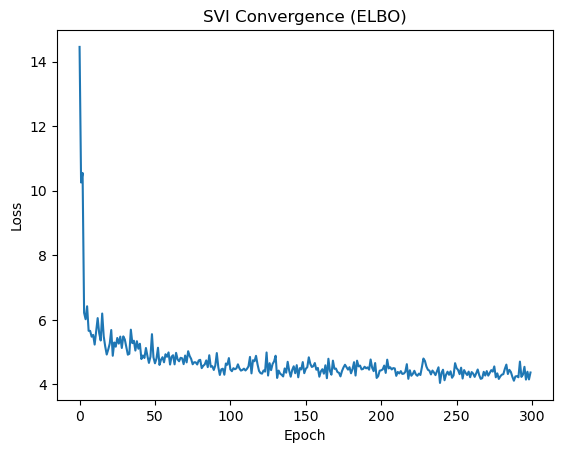

In [42]:
# Plot loss
plt.figure()
plt.plot(history)
plt.title("SVI Convergence (ELBO)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()